In [1]:
# ============================================================
# UPDATED PUBLICATION-STYLE CDF PLOTTING CODE
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Optional SciencePlots style, but disable LaTeX rendering
# so "Objective ($K)" does not crash.
# ------------------------------------------------------------
try:
    import scienceplots
    plt.style.use("science")
except Exception:
    print("SciencePlots not available; using default matplotlib style.")


# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------
PLOT_DIR = "cdf_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# ------------------------------------------------------------
# CSV files
# ------------------------------------------------------------
extension_files = {
    1: "extension_evaluation_npvs_case1.csv",
    2: "extension_evaluation_npvs_case2.csv",
    3: "extension_evaluation_npvs_case3.csv",
    4: "extension_evaluation_npvs_case4.csv",
}

extension_files_dro = {
    1: "dro_evaluation_npvs_case1.csv",
    2: "dro_evaluation_npvs_case2.csv",
    3: "dro_evaluation_npvs_case3.csv",
    4: "dro_evaluation_npvs_case4.csv",
}

multistage_files = {
    1: "multistage_common_evaluation_npvs_case1.csv",
    2: "multistage_common_evaluation_npvs_case2.csv",
    3: "multistage_common_evaluation_npvs_case3.csv",
    4: "multistage_common_evaluation_npvs_case4.csv",
}

# ------------------------------------------------------------
# Column sets
# ------------------------------------------------------------
extension_policy_cols = [
    "Multi-period",
    "Start-period",
    #"Long-chain",
    #"Decision-rule",
    #"Perfect Information",
    "Start-period RO",
    "Multi-period RO",
    "Start-period DRO",
    "Multi-period DRO",
]

multistage_policy_cols = [
    "Multistage stochastic",
    "Two-stage multi-period (multistage recourse)",
    "Two-stage start-period (multistage recourse)",
]

# ------------------------------------------------------------
# Display labels
# ------------------------------------------------------------
label_map = {
    "Multi-period": "Multi-period",
    "Start-period": "Start-period",
    "Long-chain": "Long-chain",
    "Decision-rule": "Decision-rule",
    "Perfect Information": "Perfect Information",
    "Start-period RO": "Start-period RO",
    "Multi-period RO": "Multi-period RO",
    "Start-period DRO": "Start-period DRO",
    "Multi-period DRO": "Multi-period DRO",
    "Multistage stochastic": "Multistage stochastic",
    "Two-stage multi-period (multistage recourse)": "Two-stage multi-period",
    "Two-stage start-period (multistage recourse)": "Two-stage start-period",
}

# ------------------------------------------------------------
# Publication-style colors
# Base five follow your original final plot.
# Extra methods use distinct colors.
# ------------------------------------------------------------
policy_colors = {
    "Multi-period": "#E69F00",
    "Start-period": "#56B4E9",
    "Long-chain": "#009E73",
    "Decision-rule": "#D55E00",
    "Perfect Information": "#0072B2",

    # RO policies: distinct purples/blues
    "Start-period RO": "#CC79A7",
    "Multi-period RO": "#332288",

    # DRO policies: distinct reds/browns
    "Start-period DRO": "#AA4499",
    "Multi-period DRO": "#882255",

    # Multistage comparison policies
    "Multistage stochastic": "#117733",
    "Two-stage multi-period (multistage recourse)": "#E69F00",
    "Two-stage start-period (multistage recourse)": "#56B4E9",
}

# ------------------------------------------------------------
# Line styles
# Main policies solid.
# RO dash-dot.
# DRO dashed.
# Multistage has distinct styles.
# ------------------------------------------------------------
policy_linestyles = {
    "Multi-period": "-",
    "Start-period": "-",
    "Long-chain": "-",
    "Decision-rule": "-",
    "Perfect Information": "-",

    "Start-period RO": "-",
    "Multi-period RO": "-.",

    "Start-period DRO": "--",
    "Multi-period DRO": "--",

    "Multistage stochastic": "-",
    "Two-stage multi-period (multistage recourse)": "--",
    "Two-stage start-period (multistage recourse)": "-.",
}

# ------------------------------------------------------------
# Empirical CDF helper.
# This follows the original compact final plot style:
# unweighted empirical CDF over the NPV samples.
# ------------------------------------------------------------
def make_cdf(values):
    """
    Build an empirical CDF from a vector of NPV values.

    Returns:
        x_values: sorted finite NPV values
        y_values: empirical probabilities from 1/n to 1
    """
    finite_values = np.asarray(values, dtype=float)
    finite_values = finite_values[np.isfinite(finite_values)]

    if len(finite_values) == 0:
        return np.array([]), np.array([])

    x_values = np.sort(finite_values)
    y_values = np.arange(1, len(x_values) + 1) / len(x_values)

    return x_values, y_values

# ------------------------------------------------------------
# Publication-style CDF function
# ------------------------------------------------------------
def plot_cdf_from_csv(
    csv_file,
    policy_cols,
    output_name,
    *,
    x_scale=1000.0,
    x_label="Objective (\$K)",
    x_limits=(100, 250),
    y_limits=(0.1, 1.0),
    figsize=(11, 2),
    legend_loc="lower right",
    legend_fontsize=8,
    save_pdf=True,
    save_png=True,
    show=True,
):
    """
    Plot compact publication-style CDFs from a CSV.

    This intentionally follows the original final-case CDF style:
        - no title
        - figure size 11 by 2
        - x-axis in $K
        - fixed x-axis limits
        - fixed y-axis limits
        - one CDF line per policy
        - one dotted median line per policy
    """
    df = pd.read_csv(csv_file)

    available_policy_cols = [col for col in policy_cols if col in df.columns]

    if len(available_policy_cols) == 0:
        raise ValueError(
            f"No requested policy columns found in {csv_file}.\n"
            f"Available columns are: {list(df.columns)}"
        )

    figure, axis = plt.subplots(figsize=figsize)

    for col in available_policy_cols:
        values = df[col].to_numpy(dtype=float)
        finite_values = values[np.isfinite(values)]

        if len(finite_values) == 0:
            print(f"Skipping {col}: no finite values.")
            continue

        x_values, y_values = make_cdf(finite_values)

        color = policy_colors.get(col, "#000000")
        linestyle = policy_linestyles.get(col, "-")
        display_label = label_map.get(col, col)

        axis.plot(
            x_values / x_scale,
            y_values,
            linewidth=2.5,
            color=color,
            linestyle=linestyle,
            label=display_label,
        )

        median_value = float(np.median(finite_values) / x_scale)

        # Dotted median line for every policy.
        axis.axvline(
            median_value,
            linestyle=":",
            linewidth=1.5,
            color=color,
            alpha=0.95,
        )

    axis.set_xlabel(x_label)
    axis.set_ylabel("Probability")
    axis.set_ylim(*y_limits)
    axis.set_xlim(*x_limits)
    axis.legend(loc=legend_loc, fontsize=legend_fontsize, ncol=1)

    # No title, no grid, consistent with compact publication style.
    plt.tight_layout()

    pdf_path = os.path.join(PLOT_DIR, f"{output_name}.pdf")
    png_path = os.path.join(PLOT_DIR, f"{output_name}.png")

    if save_pdf:
        figure.savefig(pdf_path, bbox_inches="tight")
        print(f"Saved: {pdf_path}")

    if save_png:
        figure.savefig(png_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {png_path}")

    if show:
        plt.show()
    else:
        plt.close(figure)



<>:174: SyntaxWarning: invalid escape sequence '\$'
<>:174: SyntaxWarning: invalid escape sequence '\$'
/var/folders/sj/st6tx4490j9cw4yh3mw2mcyh0000gp/T/ipykernel_10140/3085090581.py:174: SyntaxWarning: invalid escape sequence '\$'
  x_label="Objective (\$K)",


Saved: cdf_plots/case1_extension_cdf.pdf
Saved: cdf_plots/case1_extension_cdf.png


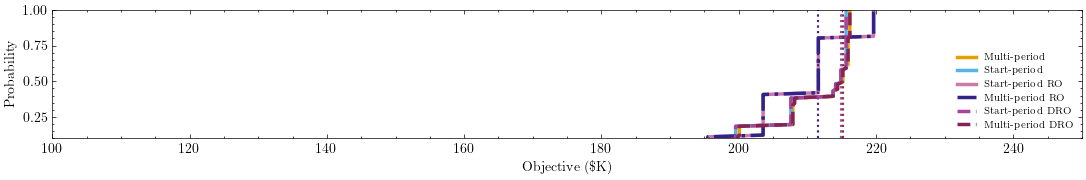

Saved: cdf_plots/case2_extension_cdf.pdf
Saved: cdf_plots/case2_extension_cdf.png


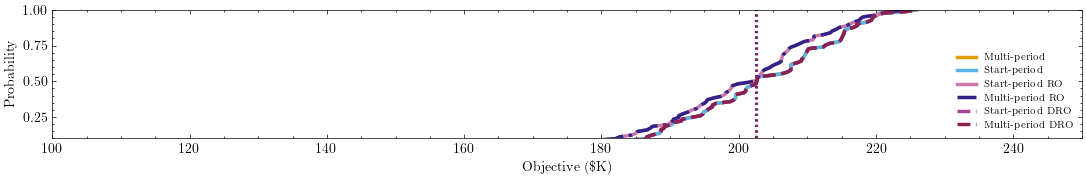

Saved: cdf_plots/case3_extension_cdf.pdf
Saved: cdf_plots/case3_extension_cdf.png


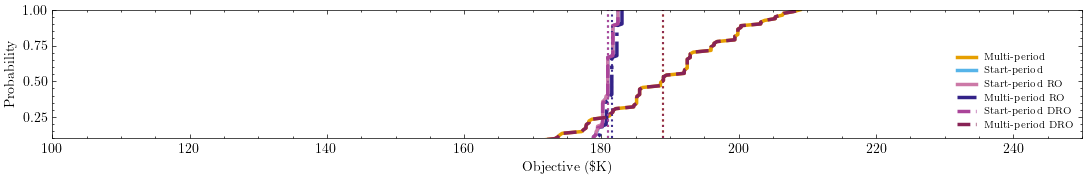

Saved: cdf_plots/case4_extension_cdf.pdf
Saved: cdf_plots/case4_extension_cdf.png


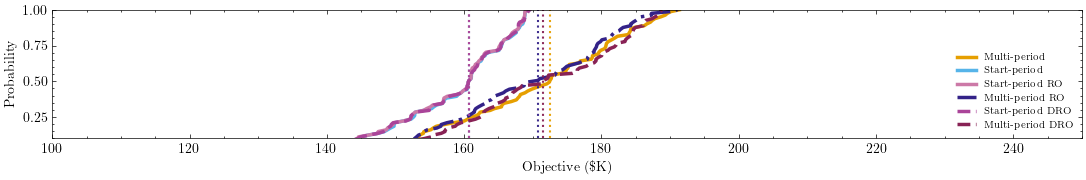

In [2]:
# ============================================================
# CREATE THE 8 CDF PLOTS
# ============================================================

# ------------------------------------------------------------
# 1. Extension-evaluation CDF plots, Cases 1–4
# ------------------------------------------------------------
for case in [1, 2, 3, 4]:
    plot_cdf_from_csv(
        csv_file=extension_files[case],
        policy_cols=extension_policy_cols,
        output_name=f"case{case}_extension_cdf",
        legend_loc="lower right",
        legend_fontsize=7,
    )


Saved: cdf_plots/dro_case1_extension_cdf.pdf
Saved: cdf_plots/dro_case1_extension_cdf.png


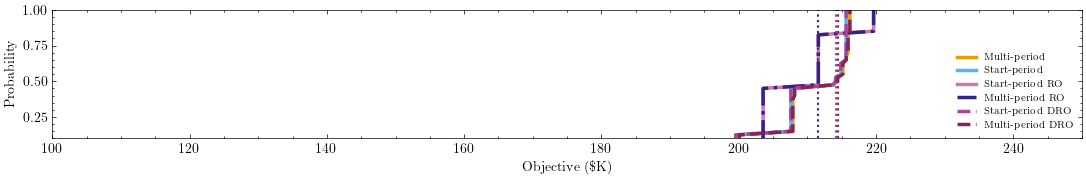

Saved: cdf_plots/dro_case2_extension_cdf.pdf
Saved: cdf_plots/dro_case2_extension_cdf.png


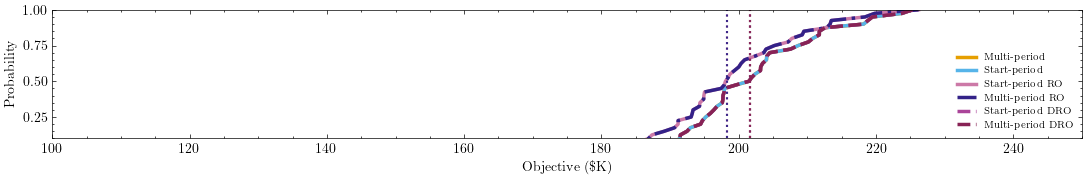

Saved: cdf_plots/dro_case3_extension_cdf.pdf
Saved: cdf_plots/dro_case3_extension_cdf.png


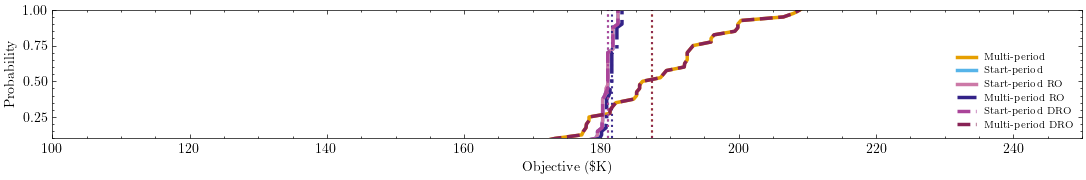

Saved: cdf_plots/dro_case4_extension_cdf.pdf
Saved: cdf_plots/dro_case4_extension_cdf.png


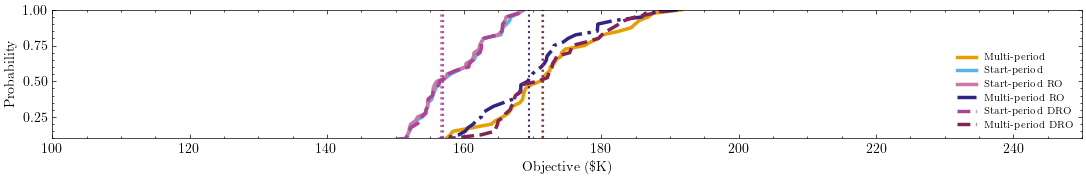

In [3]:
# ============================================================
# CREATE THE 8 CDF PLOTS
# ============================================================

# ------------------------------------------------------------
# 1. Extension-evaluation CDF plots, Cases 1–4
# ------------------------------------------------------------
for case in [1, 2, 3, 4]:
    plot_cdf_from_csv(
        csv_file=extension_files_dro[case],
        policy_cols=extension_policy_cols,
        output_name=f"dro_case{case}_extension_cdf",
        legend_loc="lower right",
        legend_fontsize=7,
    )


Saved: cdf_plots/case1_multistage_common_cdf.pdf
Saved: cdf_plots/case1_multistage_common_cdf.png


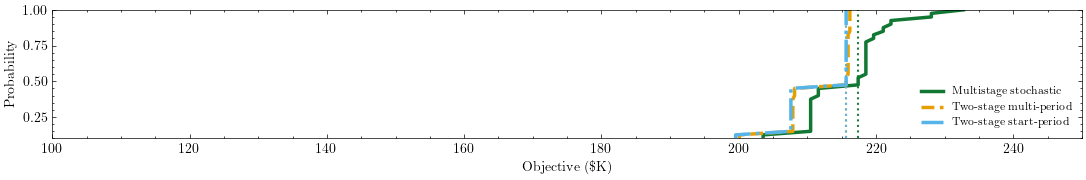

Saved: cdf_plots/case2_multistage_common_cdf.pdf
Saved: cdf_plots/case2_multistage_common_cdf.png


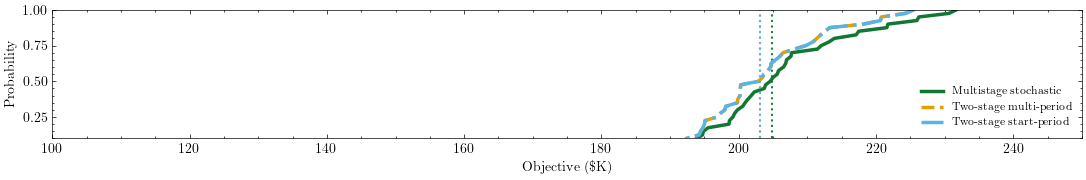

Saved: cdf_plots/case3_multistage_common_cdf.pdf
Saved: cdf_plots/case3_multistage_common_cdf.png


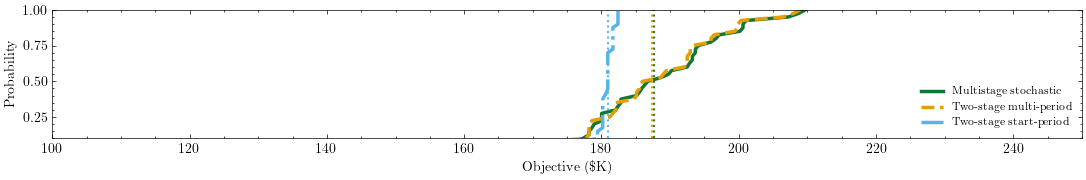

Saved: cdf_plots/case4_multistage_common_cdf.pdf
Saved: cdf_plots/case4_multistage_common_cdf.png


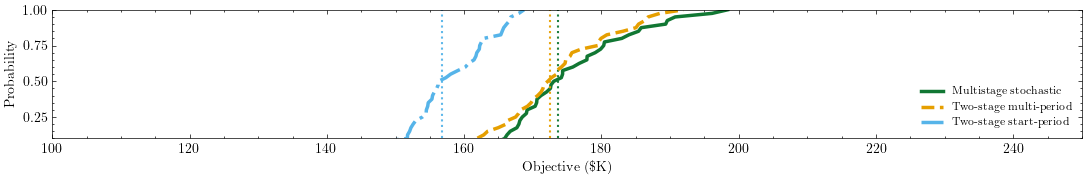

In [4]:

# ------------------------------------------------------------
# 2. Multistage-common-evaluation CDF plots, Cases 1–4
# ------------------------------------------------------------
for case in [1, 2, 3, 4]:
    plot_cdf_from_csv(
        csv_file=multistage_files[case],
        policy_cols=multistage_policy_cols,
        output_name=f"case{case}_multistage_common_cdf",
        legend_loc="lower right",
        legend_fontsize=8,
    )

In [5]:
# ============================================================
# APPENDIX B: REVISED SP / DRO / RO TABLE
# ============================================================
#
# IMPORTANT:
#   SP  = expected NPV from extension_evaluation_npvs_case*.csv
#         (the same 81-state out-of-sample evaluation used in the
#         main numerical study; probability-weighted for robustness).
#
#   DRO = policy-specific worst-case expected NPV from the DRO
#         ambiguity set. Prefer dro_evaluation_summary*.csv. If the
#         summary file is unavailable, reconstruct it from
#         dro_evaluation_npvs*.csv and
#         dro_evaluation_worst_probabilities*.csv.
#
#   RO  = NPV under the common single stress scenario from
#         ro_stress_evaluation_npvs*.csv.
#
# This avoids the previous mistake of using the nominal mean of the
# 40-scenario DRO support as the "SP" column.

from pathlib import Path
import re

CASE_NAMES = {
    1: "Stability",
    2: "SVD",
    3: "SC",
    4: "SCVD",
}

APPENDIX_B_DESIGNS = [
    "Multi-period",
    "Start-period",
    "Long-chain",
    "Decision-rule",
    "Perfect Information",
    "Start-period RO",
    "Multi-period RO",
    "Start-period DRO",
    "Multi-period DRO",
]

def _first_existing(candidates):
    """Return the first existing path from a list of candidates."""
    candidates = [Path(p) for p in candidates]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        "None of the following files exists:\n  "
        + "\n  ".join(str(p) for p in candidates)
    )

def _case_file(case, flat_name, nested_name):
    """
    Support both:
      1) flattened files used by plotcdf.ipynb, e.g.
         extension_evaluation_npvs_case1.csv
      2) original Engaging output folders, e.g.
         rosr_extended_outputs/case_1/extension_evaluation_npvs.csv
    """
    return _first_existing([
        flat_name.format(case=case),
        Path("rosr_extended_outputs") / f"case_{case}" / nested_name,
    ])

def _safe_name(text):
    return re.sub(r"[^A-Za-z0-9]+", "_", text).strip("_").lower()

def _weighted_mean(df, value_col, probability_col="probability"):
    """Probability-weighted mean; falls back to arithmetic mean if no weights exist."""
    values = pd.to_numeric(df[value_col], errors="coerce").to_numpy(dtype=float)
    finite = np.isfinite(values)

    if not finite.any():
        return np.nan

    if probability_col in df.columns:
        weights = pd.to_numeric(df[probability_col], errors="coerce").to_numpy(dtype=float)
        finite &= np.isfinite(weights) & (weights >= 0)
        values = values[finite]
        weights = weights[finite]
        if len(values) == 0 or weights.sum() <= 0:
            return np.nan
        weights = weights / weights.sum()
        return float(np.dot(weights, values))

    return float(np.mean(values[finite]))

def _read_indexed_summary(path):
    """Read a summary CSV whose design name may be in 'design' or the first column."""
    df = pd.read_csv(path)
    if "design" in df.columns:
        return df.set_index("design")

    first = df.columns[0]
    if first.startswith("Unnamed") or first not in {
        "nominal_expected_npv", "dro_worst_expected_npv", "mean"
    }:
        return df.set_index(first)

    return df

def _dro_worst_value(case, design):
    """
    Return policy-specific DRO worst expected NPV.

    Preferred source:
        dro_evaluation_summary_case{case}.csv

    Fallback:
        dro_evaluation_npvs_case{case}.csv
        + dro_evaluation_worst_probabilities_case{case}.csv
    """
    summary_candidates = [
        f"dro_evaluation_summary_case{case}.csv",
        Path("rosr_extended_outputs") / f"case_{case}" / "dro_evaluation_summary.csv",
    ]

    summary_path = next((Path(p) for p in summary_candidates if Path(p).exists()), None)
    if summary_path is not None:
        summary = _read_indexed_summary(summary_path)
        if design not in summary.index:
            raise KeyError(f"{design!r} not found in {summary_path}")
        return float(summary.loc[design, "dro_worst_expected_npv"])

    # Reconstruct exactly from the per-scenario NPV vector and that policy's
    # own worst-case probability distribution.
    npv_path = _case_file(
        case,
        "dro_evaluation_npvs_case{case}.csv",
        "dro_evaluation_npvs.csv",
    )
    prob_path = _first_existing([
        f"dro_evaluation_worst_probabilities_case{case}.csv",
        Path("rosr_extended_outputs") / f"case_{case}" / "dro_evaluation_worst_probabilities.csv",
    ])

    npv_df = pd.read_csv(npv_path)
    prob_df = pd.read_csv(prob_path)

    weight_col = f"worst_probability__{_safe_name(design)}"
    if weight_col not in prob_df.columns:
        raise KeyError(
            f"{weight_col!r} not found in {prob_path}. "
            f"Available columns: {list(prob_df.columns)}"
        )

    # Align by scenario_id whenever available.
    if "scenario_id" in npv_df.columns and "scenario_id" in prob_df.columns:
        merged = npv_df[["scenario_id", design]].merge(
            prob_df[["scenario_id", weight_col]],
            on="scenario_id",
            how="inner",
            validate="one_to_one",
        )
        values = pd.to_numeric(merged[design], errors="coerce").to_numpy(dtype=float)
        weights = pd.to_numeric(merged[weight_col], errors="coerce").to_numpy(dtype=float)
    else:
        values = pd.to_numeric(npv_df[design], errors="coerce").to_numpy(dtype=float)
        weights = pd.to_numeric(prob_df[weight_col], errors="coerce").to_numpy(dtype=float)

    finite = np.isfinite(values) & np.isfinite(weights) & (weights >= 0)
    values = values[finite]
    weights = weights[finite]

    if len(values) == 0 or weights.sum() <= 0:
        return np.nan

    weights = weights / weights.sum()
    return float(np.dot(weights, values))

def build_appendix_b_table(scale=1000.0):
    """
    Build the Appendix B cross-evaluation table.

    Returns a DataFrame in $K with MultiIndex columns:
        (Case 1: Stability, SP/DRO/RO), ..., (Case 4: SCVD, SP/DRO/RO)
    """
    records = {design: {} for design in APPENDIX_B_DESIGNS}

    for case in [1, 2, 3, 4]:
        # SP evaluation = the same 81-state common evaluation used in the main study.
        sp_path = _case_file(
            case,
            "extension_evaluation_npvs_case{case}.csv",
            "extension_evaluation_npvs.csv",
        )
        sp_df = pd.read_csv(sp_path)

        # RO evaluation = the common single stress scenario.
        ro_path = _case_file(
            case,
            "ro_stress_evaluation_npvs_case{case}.csv",
            "ro_stress_evaluation_npvs.csv",
        )
        ro_df = pd.read_csv(ro_path)

        for design in APPENDIX_B_DESIGNS:
            if design not in sp_df.columns:
                raise KeyError(f"{design!r} not found in {sp_path}")
            if design not in ro_df.columns:
                raise KeyError(f"{design!r} not found in {ro_path}")

            records[design][(f"Case {case}: {CASE_NAMES[case]}", "SP")] = (
                _weighted_mean(sp_df, design) / scale
            )
            records[design][(f"Case {case}: {CASE_NAMES[case]}", "DRO")] = (
                _dro_worst_value(case, design) / scale
            )
            records[design][(f"Case {case}: {CASE_NAMES[case]}", "RO")] = (
                _weighted_mean(ro_df, design) / scale
            )

    table = pd.DataFrame.from_dict(records, orient="index")
    table.columns = pd.MultiIndex.from_tuples(table.columns)
    table.index.name = "Design"
    return table

def appendix_b_to_latex(table):
    """Create manuscript-ready LaTeX and bold the best rounded value in each column."""
    cases = [f"Case {c}: {CASE_NAMES[c]}" for c in [1, 2, 3, 4]]
    envs = ["SP", "DRO", "RO"]

    # Bold ties at the displayed two-decimal precision.
    maxima = {}
    for case in cases:
        for env in envs:
            col = table[(case, env)]
            maxima[(case, env)] = round(float(col.max()), 2)

    lines = [
        r"\begin{table}[!ht]",
        r"\centering",
        r"\caption{Performance of SP, DRO, and RO designs under SP, DRO, and RO evaluation environments}",
        r"\label{tab:sp_dro_ro_results}",
        r"\renewcommand{\arraystretch}{0.9}",
        r"\footnotesize",
        r"\resizebox{\textwidth}{!}{%",
        r"\begin{tabular}{l ccc ccc ccc ccc}",
        r"\toprule",
        r"\multirow{2}{*}{\textbf{Design}}",
        r"& \multicolumn{3}{c}{\textbf{Case 1: Stability}}",
        r"& \multicolumn{3}{c}{\textbf{Case 2: SVD}}",
        r"& \multicolumn{3}{c}{\textbf{Case 3: SC}}",
        r"& \multicolumn{3}{c}{\textbf{Case 4: SCVD}} \\",
        r"\cmidrule(lr){2-4}",
        r"\cmidrule(lr){5-7}",
        r"\cmidrule(lr){8-10}",
        r"\cmidrule(lr){11-13}",
        r"& \textbf{SP} & \textbf{DRO} & \textbf{RO}",
        r"& \textbf{SP} & \textbf{DRO} & \textbf{RO}",
        r"& \textbf{SP} & \textbf{DRO} & \textbf{RO}",
        r"& \textbf{SP} & \textbf{DRO} & \textbf{RO} \\",
        r"\midrule",
    ]

    for row_i, design in enumerate(APPENDIX_B_DESIGNS):
        vals = []
        for case in cases:
            for env in envs:
                x = float(table.loc[design, (case, env)])
                text = f"{x:.2f}"
                if round(x, 2) == maxima[(case, env)]:
                    text = rf"\textbf{{{text}}}"
                vals.append(text)

        lines.append(design + " & " + " & ".join(vals) + r" \\")
        if design == "Perfect Information":
            lines.append(r"\midrule")

    lines.extend([
        r"\bottomrule",
        r"\end{tabular}",
        r"}",
        r"\begin{tablenotes}",
        r"\raggedright",
        r"\tiny",
        (
            r"\item Notes: Values are shown in thousands (\$K). "
            r"SP reports expected NPV under the common 81-state evaluation used in the main numerical study. "
            r"DRO reports each policy's worst-case expected NPV over the 40-scenario ambiguity-set support. "
            r"RO reports NPV under the common single severe stress scenario."
        ),
        r"\end{tablenotes}",
        r"\end{table}",
    ])
    return "\n".join(lines)

appendix_b = build_appendix_b_table()

print("APPENDIX B — revised values ($K)")
display(appendix_b.round(2))

appendix_b.to_csv("appendix_b_sp_dro_ro_table.csv")
appendix_b_latex = appendix_b_to_latex(appendix_b)

with open("appendix_b_sp_dro_ro_table.tex", "w", encoding="utf-8") as f:
    f.write(appendix_b_latex)

print("\n--- COPY-READY LATEX: APPENDIX B ---\n")
print(appendix_b_latex)


APPENDIX B — revised values ($K)


Case 1: Stability                 Case 2: SVD          \
                                   SP     DRO      RO          SP     DRO   
Design                                                                      
Multi-period                   210.60  207.98  183.99      202.33  198.49   
Start-period                   210.24  207.62  183.46      202.33  198.49   
Long-chain                     210.24  207.57  183.46      202.35  198.38   
Decision-rule                  205.17  203.19  187.46      187.27  183.41   
Perfect Information            214.21  211.13  187.46      205.68  201.56   
Start-period RO                208.92  205.97  187.46      199.83  195.69   
Multi-period RO                208.92  205.97  187.46      199.83  195.69   
Start-period DRO               210.24  207.62  183.46      202.33  198.49   
Multi-period DRO               210.60  207.98  183.99      202.33  198.49   

                            Case 3: SC                 Case 4: SCVD          \
                         RO         SP     DRO      RO           SP     DRO   
Design                                                                        
Multi-period         180.19     188.23  183.67  158.92       170.66  167.88   
Start-period         180.19     180.50  179.95  170.75       158.36  155.55   
Long-chain           180.19     166.09  161.25  139.74       155.83  152.17   
Decision-rule        150.13     178.57  175.23  156.20       148.63  145.99   
Perfect Information  184.19     190.38  185.99  171.33       177.16  173.20   
Start-period RO      184.19     180.49  179.93  170.75       158.18  155.34   
Multi-period RO      184.19     181.07  180.52  171.33       169.51  166.18   
Start-period DRO     180.19     180.50  179.95  170.75       158.32  155.56   
Multi-period DRO     180.19     188.23  183.67  158.92       171.18  168.22   

                             
                         RO  
Design                       
Multi-period         151.00  
Start-period         149.38  
Long-chain           139.29  
Decision-rule        116.98  
Perfect Information  152.49  
Start-period RO      149.38  
Multi-period RO      152.49  
Start-period DRO     149.38  
Multi-period DRO     150.94


--- COPY-READY LATEX: APPENDIX B ---

\begin{table}[!ht]
\centering
\caption{Performance of SP, DRO, and RO designs under SP, DRO, and RO evaluation environments}
\label{tab:sp_dro_ro_results}
\renewcommand{\arraystretch}{0.9}
\footnotesize
\resizebox{\textwidth}{!}{%
\begin{tabular}{l ccc ccc ccc ccc}
\toprule
\multirow{2}{*}{\textbf{Design}}
& \multicolumn{3}{c}{\textbf{Case 1: Stability}}
& \multicolumn{3}{c}{\textbf{Case 2: SVD}}
& \multicolumn{3}{c}{\textbf{Case 3: SC}}
& \multicolumn{3}{c}{\textbf{Case 4: SCVD}} \\
\cmidrule(lr){2-4}
\cmidrule(lr){5-7}
\cmidrule(lr){8-10}
\cmidrule(lr){11-13}
& \textbf{SP} & \textbf{DRO} & \textbf{RO}
& \textbf{SP} & \textbf{DRO} & \textbf{RO}
& \textbf{SP} & \textbf{DRO} & \textbf{RO}
& \textbf{SP} & \textbf{DRO} & \textbf{RO} \\
\midrule
Multi-period & 210.60 & 207.98 & 183.99 & 202.33 & 198.49 & 180.19 & 188.23 & 183.67 & 158.92 & 170.66 & 167.88 & 151.00 \\
Start-period & 210.24 & 207.62 & 183.46 & 202.33 & 198.49 & 180.19 & 180.50 & 179.95 

In [6]:
# ============================================================
# APPENDIX C: REVISED MULTISTAGE TABLE
# ============================================================
#
# IMPORTANT:
# The multistage common evaluation uses the probability column in
# multistage_common_evaluation_npvs_case*.csv. Do NOT use a simple
# arithmetic mean unless all scenario probabilities are equal.
#
# This reproduces the probability-weighted expected-NPV convention
# used by the multistage optimization.

APPENDIX_C_DESIGNS = [
    "Multistage stochastic",
    "Two-stage multi-period (multistage recourse)",
    "Two-stage start-period (multistage recourse)",
]

def build_appendix_c_table(scale=1000.0):
    rows = {design: {} for design in APPENDIX_C_DESIGNS}

    for case in [1, 2, 3, 4]:
        path = _case_file(
            case,
            "multistage_common_evaluation_npvs_case{case}.csv",
            "multistage_common_evaluation_npvs.csv",
        )
        df = pd.read_csv(path)

        if "probability" not in df.columns:
            raise KeyError(
                f"'probability' is required in {path} because Appendix C "
                "reports probability-weighted expected NPV."
            )

        for design in APPENDIX_C_DESIGNS:
            if design not in df.columns:
                raise KeyError(f"{design!r} not found in {path}")
            rows[design][f"Case {case}: {CASE_NAMES[case]}"] = (
                _weighted_mean(df, design) / scale
            )

    table = pd.DataFrame.from_dict(rows, orient="index")
    table.index.name = "Design"
    return table

def appendix_c_to_latex(table):
    lines = [
        r"\begin{table}[!ht]",
        r"\centering",
        r"\caption{Mean \ac{NPV} under common multistage-recourse evaluation}",
        r"\label{tab:multistage_results}",
        r"\renewcommand{\arraystretch}{0.9}",
        r"\footnotesize",
        r"\resizebox{\textwidth}{!}{%",
        r"\begin{tabular}{l c c c c}",
        r"\toprule",
        r"\textbf{Design}",
        r"& \textbf{Case 1: Stability}",
        r"& \textbf{Case 2: SVD}",
        r"& \textbf{Case 3: SC}",
        r"& \textbf{Case 4: SCVD} \\",
        r"\midrule",
    ]

    for design in APPENDIX_C_DESIGNS:
        values = [
            float(table.loc[design, f"Case {case}: {CASE_NAMES[case]}"])
            for case in [1, 2, 3, 4]
        ]
        lines.append(
            design
            + " & "
            + " & ".join(f"{x:.1f}" for x in values)
            + r" \\"
        )

    lines.extend([
        r"\bottomrule",
        r"\end{tabular}",
        r"}",
        r"\begin{tablenotes}",
        r"\raggedright",
        r"\tiny",
        (
            r"\item Notes: Values are probability-weighted expected NPV over the common "
            r"scenario-tree paths and are shown in thousands (\$K). "
            r"All designs are evaluated under the same fully flexible operational-recourse "
            r"environment, without the post-investment frozen-share constraints."
        ),
        r"\end{tablenotes}",
        r"\end{table}",
    ])
    return "\n".join(lines)

appendix_c = build_appendix_c_table()

print("APPENDIX C — revised probability-weighted expected NPV ($K)")
display(appendix_c.round(3))

# Diagnostics used in the Appendix C discussion.
diag_rows = []
for case in [1, 2, 3, 4]:
    col = f"Case {case}: {CASE_NAMES[case]}"
    ms = float(appendix_c.loc["Multistage stochastic", col])
    mp = float(appendix_c.loc["Two-stage multi-period (multistage recourse)", col])
    sp = float(appendix_c.loc["Two-stage start-period (multistage recourse)", col])

    mp_below_ms_pct = 100.0 * (ms - mp) / ms if ms != 0 else np.nan
    vmp_share_vms_pct = (
        100.0 * (mp - sp) / (ms - sp)
        if not np.isclose(ms, sp)
        else np.nan
    )

    diag_rows.append({
        "case": case,
        "multistage": ms,
        "two_stage_multi": mp,
        "two_stage_start": sp,
        "multi_below_multistage_pct": mp_below_ms_pct,
        "VMP_share_of_VMS_pct": vmp_share_vms_pct,
    })

appendix_c_diagnostics = pd.DataFrame(diag_rows).set_index("case")
print("\nAPPENDIX C — discussion diagnostics")
display(appendix_c_diagnostics.round(2))

appendix_c.to_csv("appendix_c_multistage_table.csv")
appendix_c_diagnostics.to_csv("appendix_c_multistage_diagnostics.csv")

appendix_c_latex = appendix_c_to_latex(appendix_c)
with open("appendix_c_multistage_table.tex", "w", encoding="utf-8") as f:
    f.write(appendix_c_latex)

print("\n--- COPY-READY LATEX: APPENDIX C ---\n")
print(appendix_c_latex)


APPENDIX C — revised probability-weighted expected NPV ($K)


,Case 1: Stability,Case 2: SVD,Case 3: SC,Case 4: SCVD
Design,,,,
Multistage stochastic,214.633,206.484,189.086,175.736
Two-stage multi-period (multistage recourse),210.776,203.810,188.413,173.472
Two-stage start-period (multistage recourse),210.419,203.810,180.503,158.143



APPENDIX C — discussion diagnostics


,multistage,two_stage_multi,two_stage_start,multi_below_multistage_pct,VMP_share_of_VMS_pct
case,,,,,
1,214.63,210.78,210.42,1.80,8.47
2,206.48,203.81,203.81,1.30,0.00
3,189.09,188.41,180.50,0.36,92.16
4,175.74,173.47,158.14,1.29,87.13



--- COPY-READY LATEX: APPENDIX C ---

\begin{table}[!ht]
\centering
\caption{Mean \ac{NPV} under common multistage-recourse evaluation}
\label{tab:multistage_results}
\renewcommand{\arraystretch}{0.9}
\footnotesize
\resizebox{\textwidth}{!}{%
\begin{tabular}{l c c c c}
\toprule
\textbf{Design}
& \textbf{Case 1: Stability}
& \textbf{Case 2: SVD}
& \textbf{Case 3: SC}
& \textbf{Case 4: SCVD} \\
\midrule
Multistage stochastic & 214.6 & 206.5 & 189.1 & 175.7 \\
Two-stage multi-period (multistage recourse) & 210.8 & 203.8 & 188.4 & 173.5 \\
Two-stage start-period (multistage recourse) & 210.4 & 203.8 & 180.5 & 158.1 \\
\bottomrule
\end{tabular}
}
\begin{tablenotes}
\raggedright
\tiny
\item Notes: Values are probability-weighted expected NPV over the common scenario-tree paths and are shown in thousands (\$K). All designs are evaluated under the same fully flexible operational-recourse environment, without the post-investment frozen-share constraints.
\end{tablenotes}
\end{table}
